In [55]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
from pandas_profiling import ProfileReport

In [125]:
df_matches = pd.read_csv('/home/vietnguyen/football-ai-colab-/final/Final_Matches(24-25).csv')
df_lineup = pd.read_csv('/home/vietnguyen/football-ai-colab-/final/Final_players_stats (2).csv')

In [126]:
df_matches.tail()

,MatchID,Date,HomeTeam,AwayTeam,homeTeamWinner,awayTeamWinner,homeTeamScore,awayTeamScore,HomeDef,HomeAtk,HomeGk,AwayDef,AwayAtk,AwayGk
375,376,2025-05-25 15:00:00,Wolverhampton Wanderers,Brentford,False,False,1,1,18.395562,19.093701,8.441498,20.336334,11.883870,19.286778
376,377,2025-05-25 15:00:00,Nottingham Forest,Chelsea,False,True,0,1,15.878675,20.775460,20.258333,29.097280,17.044334,19.331667
377,378,2025-05-25 15:00:00,Southampton,Arsenal,False,True,1,2,21.629771,12.389190,3.878991,15.684995,27.683544,20.758603
378,379,2025-05-25 15:00:00,Tottenham Hotspur,Brighton & Hove Albion,False,True,1,4,20.635264,15.045694,4.048830,14.690903,25.231385,17.694624
379,380,2025-05-25 15:00:00,Manchester United,Aston Villa,True,False,2,0,19.559019,21.216109,19.883333,17.012542,22.764131,26.418408


In [127]:
df_lineup['eventId'] = df_lineup['eventId'] - 704278

In [128]:
df_lineup = df_lineup[df_lineup['eventId'] < 381]

In [129]:
df_lineup.tail()

,eventId,teamId,homeAway,starter,athleteDisplayName,Pos,Age,Min/Match,Save%,GA/Match,...,PrgR,SoT%,Sh/90,ATK,DEF,GK,Rating,ATK_team,DEF_team,GK_team
15502,380,Aston Villa,away,0,Donyell Malen,FW,25.0,21.79,NaN,NaN,...,30.0,60.0,4.43,0.000000,0.000000,0.0,0.000000,22.764131,17.012542,26.418408
15503,380,Aston Villa,away,0,Lucas Digne,DF,31.0,73.47,NaN,NaN,...,NaN,NaN,NaN,0.000000,38.511818,0.0,38.511818,22.764131,17.012542,26.418408
15504,380,Aston Villa,away,0,Jacob Ramsey,"FW,MF",23.0,55.97,NaN,NaN,...,114.0,21.1,1.05,25.623940,0.000000,0.0,17.936758,22.764131,17.012542,26.418408
15505,380,Aston Villa,away,0,Ross Barkley,MF,30.0,29.05,NaN,NaN,...,NaN,NaN,NaN,9.665585,0.000000,0.0,5.799351,22.764131,17.012542,26.418408
15506,380,Aston Villa,away,0,Andrés García,"DF,MF",21.0,45.43,NaN,NaN,...,NaN,NaN,NaN,4.112103,18.738580,0.0,13.619313,22.764131,17.012542,26.418408


In [130]:
df_home_win = df_matches[df_matches['homeTeamWinner']==True]
df_home_win = df_home_win.drop(columns=['AwayTeam','homeTeamWinner','awayTeamWinner','awayTeamScore'])
df_home_win = df_home_win.rename(columns={'eventId':'MatchID','HomeTeam':'teamId'})
df_home_win.head()

,MatchID,Date,teamId,homeTeamScore,HomeDef,HomeAtk,HomeGk,AwayDef,AwayAtk,AwayGk
0,1,2024-08-16 19:00:00,Manchester United,1,19.559019,21.216109,19.883333,20.426043,18.088505,15.108333
2,3,2024-08-17 14:00:00,Arsenal,2,15.684995,27.683544,20.758603,18.395562,19.093701,8.441498
4,5,2024-08-17 14:00:00,Newcastle United,1,17.845824,14.660015,24.745256,21.629771,12.389190,3.878991
7,8,2024-08-18 13:00:00,Brentford,2,20.336334,11.883870,19.286778,23.384688,13.894073,22.490417
10,11,2024-08-24 11:30:00,Brighton & Hove Albion,2,14.690903,25.231385,17.694624,19.559019,21.216109,19.883333


In [131]:
len(df_home_win)

155

In [132]:
df_home_win = pd.merge(df_home_win, df_lineup, left_on=['MatchID','teamId'], right_on=['eventId','teamId'], how='right')

In [133]:
df_home_win.head()

,MatchID,Date,teamId,homeTeamScore,HomeDef,HomeAtk,HomeGk,AwayDef,AwayAtk,AwayGk,...,PrgR,SoT%,Sh/90,ATK,DEF,GK,Rating,ATK_team,DEF_team,GK_team
0,1.0,2024-08-16 19:00:00,Manchester United,1.0,19.559019,21.216109,19.883333,20.426043,18.088505,15.108333,...,NaN,NaN,NaN,0.000000,0.000000,19.883333,19.883333,21.216109,19.559019,19.883333
1,1.0,2024-08-16 19:00:00,Manchester United,1.0,19.559019,21.216109,19.883333,20.426043,18.088505,15.108333,...,NaN,NaN,NaN,0.000000,41.314408,0.000000,41.314408,21.216109,19.559019,19.883333
2,1.0,2024-08-16 19:00:00,Manchester United,1.0,19.559019,21.216109,19.883333,20.426043,18.088505,15.108333,...,NaN,NaN,NaN,0.000000,41.643593,0.000000,41.643593,21.216109,19.559019,19.883333
3,1.0,2024-08-16 19:00:00,Manchester United,1.0,19.559019,21.216109,19.883333,20.426043,18.088505,15.108333,...,NaN,NaN,NaN,7.417368,0.000000,0.000000,4.450421,21.216109,19.559019,19.883333
4,1.0,2024-08-16 19:00:00,Manchester United,1.0,19.559019,21.216109,19.883333,20.426043,18.088505,15.108333,...,NaN,NaN,NaN,0.000000,43.860164,0.000000,43.860164,21.216109,19.559019,19.883333


In [134]:
df_home_win.columns

Index(['MatchID', 'Date', 'teamId', 'homeTeamScore', 'HomeDef', 'HomeAtk',
       'HomeGk', 'AwayDef', 'AwayAtk', 'AwayGk', 'eventId', 'homeAway',
       'starter', 'athleteDisplayName', 'Pos', 'Age', 'Min/Match', 'Save%',
       'GA/Match', 'CS%', 'PKsv%', 'Clr/Match', 'TklW%', 'Blocks/Match',
       'Int/Match', 'Err/Match', 'G+A/Match', 'xAG', 'PrgC', 'PrgP',
       'KP/Match', 'G+A-PK/Match', 'npxG', 'PrgR', 'SoT%', 'Sh/90', 'ATK',
       'DEF', 'GK', 'Rating', 'ATK_team', 'DEF_team', 'GK_team'],
      dtype='object')

In [138]:
df_home_win.isna().sum()

MatchID               0
Date                  0
teamId                0
homeTeamScore         0
HomeDef               0
HomeAtk               0
HomeGk                0
AwayDef               0
AwayAtk               0
AwayGk                0
eventId               0
homeAway              0
starter               0
athleteDisplayName    0
Pos                   0
Age                   0
Min/Match             0
Save%                 0
GA/Match              0
CS%                   0
PKsv%                 0
Clr/Match             0
TklW%                 0
Blocks/Match          0
Int/Match             0
Err/Match             0
G+A/Match             0
xAG                   0
PrgC                  0
PrgP                  0
KP/Match              0
G+A-PK/Match          0
npxG                  0
PrgR                  0
SoT%                  0
Sh/90                 0
ATK                   0
DEF                   0
GK                    0
Rating                0
ATK_team              0
DEF_team        

In [137]:
df_home_win = df_home_win.fillna(0)

In [140]:
df_away_win = df_matches[df_matches['awayTeamWinner']==True]
df_away_win = df_away_win.drop(columns=['HomeTeam','homeTeamWinner','awayTeamWinner','homeTeamScore'],axis=1)
df_away_win = df_away_win.rename(columns={'eventId':'MatchID','AwayTeam':'teamId'})
df_away_win.head()

,MatchID,Date,teamId,awayTeamScore,HomeDef,HomeAtk,HomeGk,AwayDef,AwayAtk,AwayGk
1,2,2024-08-17 11:30:00,Liverpool,2,20.208581,9.792978,-4.724468,23.299704,13.374746,33.055102
3,4,2024-08-17 14:00:00,Brighton & Hove Albion,3,26.646686,8.940912,39.416667,14.690903,25.231385,17.694624
6,7,2024-08-17 16:30:00,Aston Villa,2,18.196913,16.922827,8.641667,17.012542,22.764131,26.418408
8,9,2024-08-18 15:30:00,Manchester City,2,29.097280,17.044334,19.331667,16.806614,31.388623,16.298775
11,12,2024-08-24 14:00:00,West Ham United,2,23.384688,13.894073,22.490417,18.196913,16.922827,8.641667


In [141]:
df_away_win = pd.merge(df_away_win, df_lineup, left_on=['MatchID','teamId'], right_on=['eventId','teamId'], how='right')

In [142]:
home_win = ProfileReport(df_home_win,title='Home Win Eda Report')
home_win.to_file("homewin.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00,  9.44it/s]


In [143]:
away_win = ProfileReport(df_away_win,title='Away Win Eda Report')
away_win.to_file("awaywin.html")

Summarize dataset:  90%|█████████ | 45/50 [00:00<00:00, 99.64it/s, Calculate auto correlation]/home/vietnguyen/miniconda3/envs/rapids-25.12/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/vietnguyen/miniconda3/envs/rapids-25.12/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/vietnguyen/miniconda3/envs/rapids-25.12/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/vietnguyen/miniconda3/envs/rapids-25.12/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/

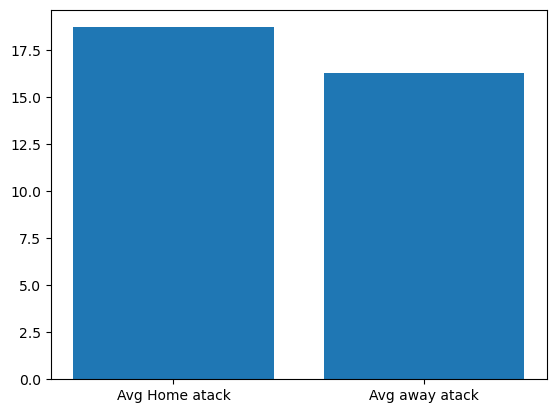

In [ ]:
Avg_Home_atk = df_home_win['HomeAtk'].mean()
Avg_Away_atk = df_home_win['AwayAtk'].mean()

plt.bar(['Avg Home atack','Avg away atack'],[Avg_Home_atk,Avg_Away_atk])
plt.show()

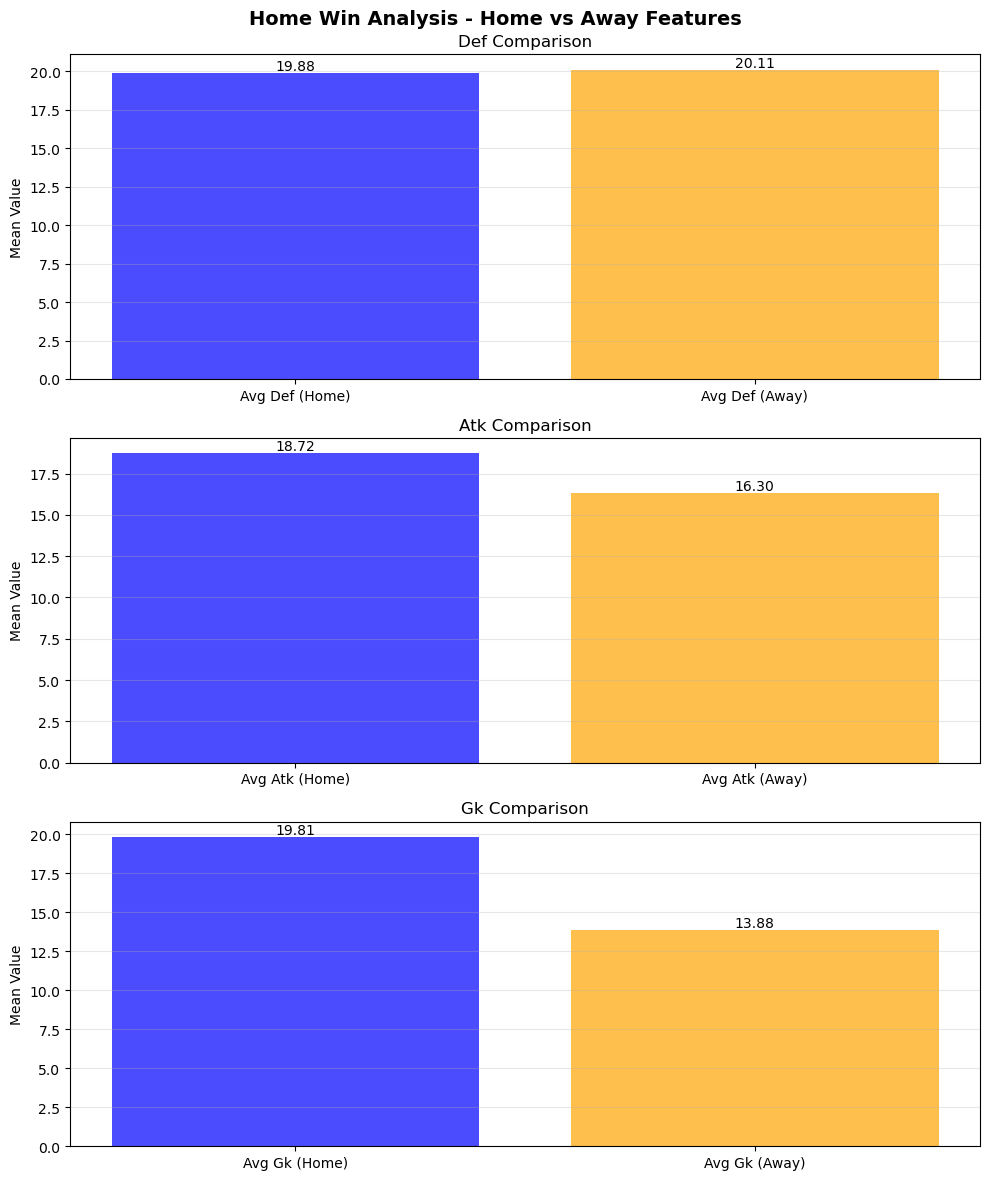

In [25]:
def plot_home_away_comparison(df, title="Home vs Away Features Comparison"):
    # Get all unique feature names by removing 'Home' or 'Away' prefix
    home_cols = [col for col in df.columns if col.startswith(('Home','Away'))]
    
    # Extract feature names (without Home/Away prefix)
    features = []
    for col in home_cols:
        feature_name = col.replace('Home', '')
        away_col = f'Away{feature_name}'
        if away_col in df.columns:
            features.append((col, away_col, feature_name))
    
    # Create subplots for each feature comparison
    n_features = len(features)
    fig, axes = plt.subplots(n_features, 1, figsize=(10, 4 * n_features))
    
    # Handle case where there's only one feature
    if n_features == 1:
        axes = [axes]
    
    # Plot each feature comparison
    for idx, (home_col, away_col, feature_name) in enumerate(features):
        avg_home = df[home_col].mean()
        avg_away = df[away_col].mean()
        
        ax = axes[idx]
        bars = ax.bar([f'Avg {feature_name} (Home)', f'Avg {feature_name} (Away)'], 
                       [avg_home, avg_away], 
                       color=['blue', 'orange'], 
                       alpha=0.7)
        
        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}',
                   ha='center', va='bottom')
        
        ax.set_ylabel('Mean Value')
        ax.set_title(f'{feature_name} Comparison')
        ax.grid(axis='y', alpha=0.3)
    
    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Test the function
plot_home_away_comparison(df_home_win, title="Home Win Analysis - Home vs Away Features")

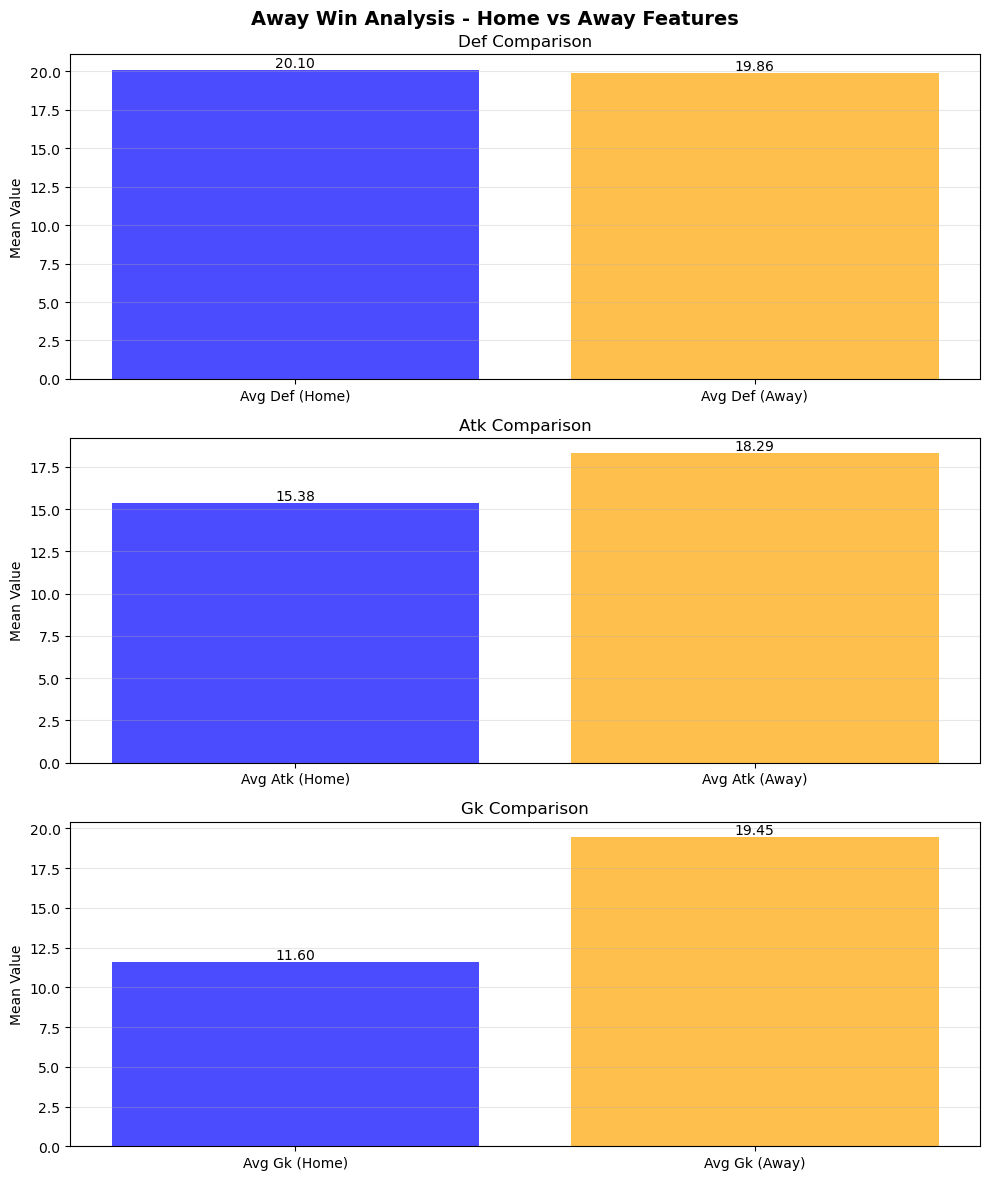

In [26]:
plot_home_away_comparison(df_away_win, title="Away Win Analysis - Home vs Away Features")


In [ ]:
away_win = ProfileReport(df_away_win, title="Away Win EDA Report")
away_win.to_file("awaywin.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 394.68it/s]
